In [3]:
import pocam_light
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import hephaistos as hp
#hp.selectDevice(0)
import hephaistos.pipeline as pl
from theia.volume import Attenuating
import theia
import theia.units as u
from pathlib import Path
from theia.compiler import addIncludeDir
import Ice_layers
import material_ice
addIncludeDir(Path("shader"))
from theia.ray import UnpolarizedRay
from theia.target import SphereTargetGuide


In [4]:
stack = Ice_layers.LayerStack("icemodel.dat")

## Parameter für sphereLight

In [5]:
light_position = (46.9072, -56.5889, -385.93)
wavelength = theia.light.ConstWavelengthSource(405.0 * u.nm)
medium_idx = stack.get_medium_index(light_position[2])
print(stack.material_store.media["Layer_124"])

125


### Target

In [6]:
targetGuide = SphereTargetGuide(
    position=(31.25, -72.93, -383.40) * u.m,
    radius=0.1651 * u.m,
)

## Paramter für SceneForwardTracer

In [7]:
batchSize = 10_000_000
max_path_length= 50
ray = UnpolarizedRay()
sphereLight = pocam_light.PocamLightSource(
    wavelength,
    mediumIdx=medium_idx,
)


response = theia.response.HistogramHitResponse(
    theia.response.UniformValueResponse(),
    binCount=200,
    binSize= 2.0 * u.ns,
    t0 = 90 * u.ns
)
rng = theia.random.PhiloxRNG(key=0xABBA)
scene = stack.scene

stats = theia.trace.EventStatisticCallback()

In [8]:
sphereTracer = theia.trace.SceneForwardTracer(
    batchSize,
    ray,
    sphereLight,
    response,
    rng,
    scene,
    targetId=1,
    targetGuide=targetGuide,
    maxPathLength=max_path_length,
    callback = stats,
    #DisableTargetSampling = False
)


In [9]:
tasks = [
    ("sphere", {
        "lightSource__budget": 1e10
        
        ,
        "lightSource__position": (
            46.9072,
            -56.5889,
            -385.93,
        ) * u.m,
    }),
]

### Tests 

In [10]:
print(len(stack.instances))#es sollen 171 sein (1 Detektor und 170 boundary planes)

171


In [11]:
print(stack.materials[-1].name) # DOM

DOM


In [12]:
print(stack.instances[-1].material)

DOM


In [13]:
import numpy as np
import theia.units as u
from material_ice import LayerMediumModel
from Ice_layers import LayerStack

ice_model = LayerStack("icemodel.dat")

lam = np.array([405.0 * u.nm])

for i in [123, 124]:

    model = LayerMediumModel(
        be400=ice_model.be400[i],
        adust400=ice_model.adust400[i],
        delta_tau=ice_model.delta_tau[i],
        g=0.9,
        fSL=0.35,
        name=f"Layer_{i}",
    )

    be_405 = (
        ice_model.be400[i]
        * (405.0 / 400.0)**(-model.kappa)
    )

    b_405 = model.scattering_coef(lam)[0]
    a_405 = model.absorption_coef(lam)[0]

    print(f"\n--- Layer {i} ---")
    print("z center        =", ice_model.z[i])
    print("be400           =", ice_model.be400[i])
    print("adust400        =", ice_model.adust400[i])
    print("delta_tau       =", ice_model.delta_tau[i])

    print("be(405)         =", be_405)
    print("b(405)          =", b_405)
    print("scattering len  =", 1.0 / b_405)
    print("effective len   =", 1.0 / be_405)

    print("a(405)          =", a_405)
    print("absorption len  =", 1.0 / a_405)


--- Layer 123 ---
z center        = -380.39999999999986
be400           = 0.0177471
adust400        = 0.00415293
delta_tau       = 14.044
be(405)         = 0.017509695986207448
b(405)          = 0.17550091089064093
scattering len  = 5.697976124027786
effective len   = 57.1112143116425
a(405)          = 0.004732535226839153
absorption len  = 211.30323432751229

--- Layer 124 ---
z center        = -390.39999999999986
be400           = 0.0188045
adust400        = 0.00464663
delta_tau       = 14.312
be(405)         = 0.01855295108342422
b(405)          = 0.1859575298974513
scattering len  = 5.377571967919035
effective len   = 53.89978098381507
a(405)          = 0.005221123577760466
absorption len  = 191.52965546717385


## Submit Work

In [14]:
spherePipeline = pl.Pipeline(sphereTracer.collectStages())

hists = []
def process(config: int, batch: int, args: None) -> None:
    hists.append(response.result(config).copy())


pipelineMap = {
    "sphere": spherePipeline,
}


scheduler = pl.PipelineScheduler(pipelineMap, processFn=process)

scheduler.schedule(tasks)

scheduler.wait()


In [15]:
t = (
    np.arange(response.binCount) * response.binSize + response.t0
) / u.ns

sphereSignal = np.mean(hists[:50], 0)
sphereSignalNorm = sphereSignal/ (
    np.sum(sphereSignal) * response.binSize / u.ns
)


print(f"Batchsize:  {batchSize}")
print(f"MaxPathLength:  {max_path_length}")
print(f"Signal:   {np.sum(sphereSignal)}")
print(stats)

Batchsize:  10000000
MaxPathLength:  50
Signal:   1142203.7489035823
 absorbed: 1,666
  created: 10,000,000
  decayed: 0
 detected: 0
    error: 0
      hit: 0
     lost: 0
  maxIter: 9,997,854
 mismatch: 480
   missed: 0
scattered: 376,407,506
   volume: 93,518,529


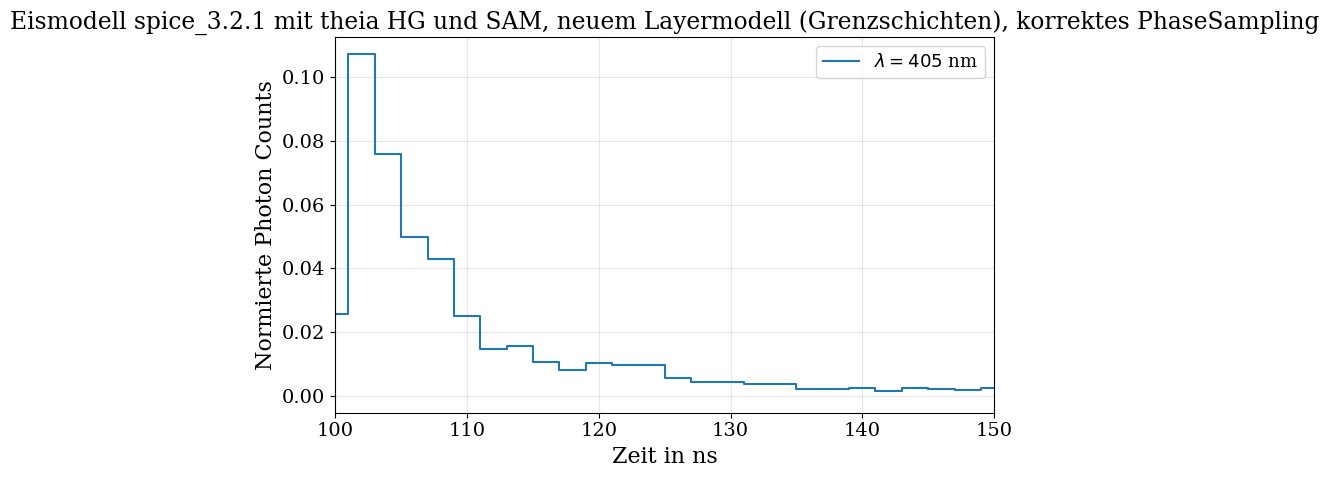

In [23]:
plt.figure(figsize=(8,5))
plt.step(
    t,
    sphereSignalNorm,
    where="mid",
    linewidth=1.5,
    label=r"$\lambda = 405$ nm"
)

plt.xlabel("Zeit in ns")
plt.ylabel("Normierte Photon Counts")
plt.title(r"Eismodell spice_3.2.1 mit theia HG und SAM, neuem Layermodell (Grenzschichten), korrektes PhaseSampling")
#plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlim(100,150)
plt.legend()

plt.tight_layout()
plt.savefig("Histogramme/1_withsc_withlayers_HGSAM_Grenzschichtmodell_korrektesPhasesampling.pdf")
plt.show()


## IceTray 

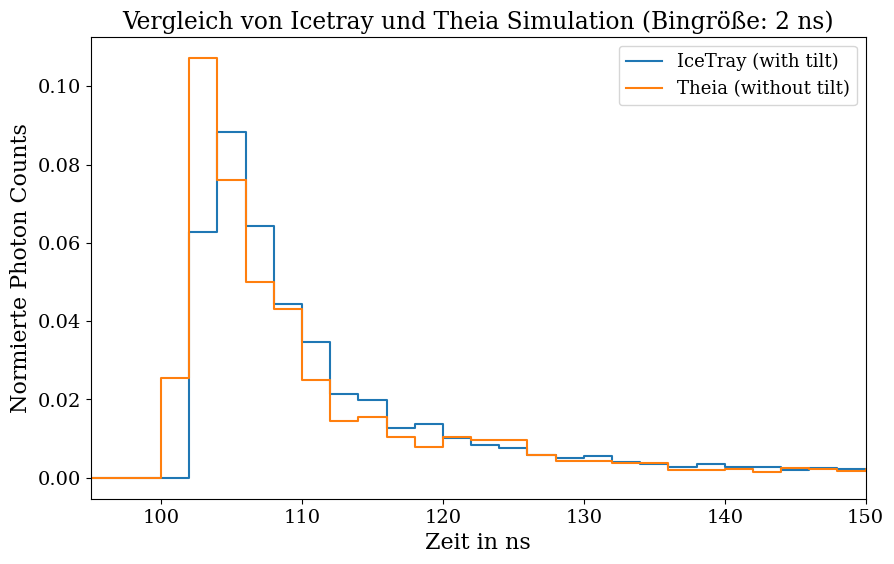

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Datei laden
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "legend.fontsize": 13
})

ice = np.loadtxt(
    "/home/stud/ph/go56sit/go56sit/theia/bachelorarbeit/Icetray/hist_10000000_100_spice_3_2_1.txt"
)

ice_left = ice[:, 0]
ice_right = ice[:, 1]
ice_counts = ice[:, 2]

ice_center = 0.5 * (ice_left + ice_right)

# same bins as Theia
theia_bin_size = 2.0
theia_t0 = 90.0

edges = (
    theia_t0
    + np.arange(len(sphereSignal) + 1) * theia_bin_size
)

#Icetray soll dieselbe Bingröße haben wie Theia histogramm
ice_rebinned, _ = np.histogram(
    ice_center,
    bins=edges,
    weights=ice_counts,
)

# Compare probability density
ice_density = (
    ice_rebinned
    / np.sum(ice_rebinned)
    / theia_bin_size
)

theia_density = (
    sphereSignal
    / np.sum(sphereSignal)
    / theia_bin_size
)


centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(10, 6))

plt.step(
    centers,
    ice_density,
    where="mid",
    label="IceTray (with tilt)",
)

plt.step(
    centers,
    theia_density,
    where="mid",
    label="Theia (without tilt)",
)

plt.xlabel("Zeit in ns")
plt.ylabel(r"Normierte Photon Counts")
plt.title("Vergleich von Icetray und Theia Simulation (Bingröße: 2 ns)")
plt.xlim(95, 150)
plt.legend()
plt.savefig("Histogramme/1VergleichTheiaIceTray.pdf")
plt.savefig("Histogramme/1VergleichTheiaIceTray.png")


plt.show()

### Wahrscheinllichkeitsverteilung Tests

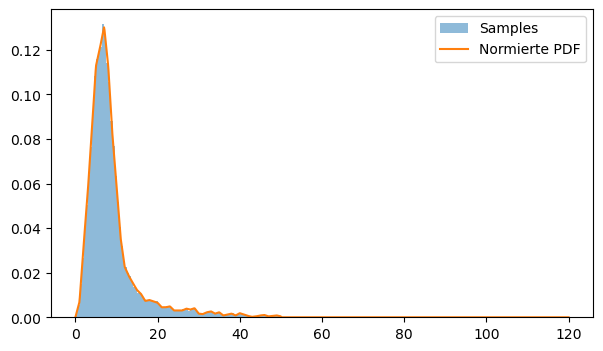

In [92]:
# Test, ob NumericalInversePolynomial die richtige Wahrscheinlichkeitsverteilung samplet

from scipy.stats.sampling import NumericalInversePolynomial
import numpy as np
import matplotlib.pyplot as plt
from pocam_light import _the_pulse

class Dist:
    def pdf(self, x):
        return _the_pulse(x, 15.0) 
                                   #NumericalInversePolynomial() erwartet nämlich ein Objekt das von Dist() erzeugt
                                   #wird und eine Methode pdf(x) besitzt

inv_cdf = NumericalInversePolynomial(
    Dist(),
    domain=(0.0, 120.0),              #erwartet ein Objekt mit Mehode
)
samples = inv_cdf.rvs(size=100000)

plt.figure(figsize=(7,4))

x = np.linspace(0,120,1000)

pdf = _the_pulse(x, 15)
pdf /= np.trapezoid(pdf, x)   # Nomirern!!

plt.hist(samples, bins=100, density=True, alpha=0.5, label="Samples") # density= TRue zur Normierung
plt.plot(x, pdf, label="Normierte PDF")

plt.legend()
plt.show()

In [ ]:
#Test, ob die Pocam-Lightsource funktioniert und Vergl. der Zeiten mit den zeiten der pulse_fkt

import pytest

import numpy as np
import scipy.integrate as integrate
import scipy.stats as stats

import hephaistos as hp
from hephaistos.pipeline import Pipeline, PipelineScheduler, runPipeline
from hephaistos.queue import dumpQueue
from ctypes import Structure, c_float

import theia.light
import theia.units as u
from theia.compiler import compileShader
from theia.material import MaterialStore, PureWaterModel, VACUUM_IDX
from theia.random import PhiloxRNG
from theia.ray import UnpolarizedRay
from theia.testing import BackwardLightSampler

N = 32 * 256
position = (14.0, -2.0, 3.0) * u.m
budget = 12.0

ray = UnpolarizedRay()
philox = PhiloxRNG(key=0xC0110FFC0FFEE)

photons = theia.light.ConstWavelengthSource(
    wavelength=100.0 * u.nm
)

light = pocam_light.PocamLightSource(
    photons,
    position=position,
    budget=budget,
    mediumIdx=VACUUM_IDX,
)

sampler = theia.light.LightSampler(
    N,
    light,
    ray,
    rng=philox,
)

runPipeline(sampler.collectStages())

result = sampler.queue.view(0)

plt.figure(figsize=(8,5))
plt.hist(times, bins=100, density=True, alpha=0.5, label="PocamLightSource")

x = np.linspace(0,120,1000)
pdf = _the_pulse(x,15)
pdf /= np.trapezoid(pdf, x)

plt.plot(x, pdf, lw=2, label=" _the_pulse (normiet)")

plt.legend()
plt.show()


In [ ]:
!git --version